# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation
## Project: Predicting Boston Housing Prices

Welcome to the first project of the Machine Learning Engineer
### first project 
* 
read the housing dataset and show the first 5 linef 

In [39]:
# Import libraries necessary for this project
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import visuals as vs # Supplementary code
import matplotlib
import matplotlib.pyplot as plt
# %matplotlib inline

from sklearn.model_selection import (
    train_test_split, ShuffleSplit,
    learning_curve, validation_curve, GridSearchCV
)
from sklearn.model_selection import ShuffleSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, make_scorer


#### read the data saved on the same location and display it 

In [40]:

# Pretty display for notebooks
%matplotlib inline

# Load the Boston housing dataset
data = pd.read_csv('housing.csv')


* gathering all information about dataset
* 1- type of all data
* shape of the data
* read the statistics of this data
* read the statistic of the MEDV feature and see if they are any outliers or missing values

In [41]:
print('types of Data:')
print(data.dtypes)
print()

print(f'Shape of Data : {data.shape[0]} rows × {data.shape[1]} columns')
print()

print('General Statistics:')
data.describe()

types of Data:
RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

Shape of Data : 489 rows × 4 columns

General Statistics:


,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [42]:
print('Statistics for MEDV:')
print(data['MEDV'].describe())
print()

print('Number of houses worth more than $1,000,000:', (data['MEDV'] >= 50).sum())
print(data.isnull().sum())

Statistics for MEDV:
count    4.890000e+02
mean     4.543429e+05
std      1.653403e+05
min      1.050000e+05
25%      3.507000e+05
50%      4.389000e+05
75%      5.187000e+05
max      1.024800e+06
Name: MEDV, dtype: float64

Number of houses worth more than $1,000,000: 489
RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64


* on the code below i assign new var for the prediction column and drop it from original dataset
* i assigne the prediction column as a price and other column as a features data

In [43]:
prices = data['MEDV']
features = data.drop('MEDV', axis = 1)
# print the shape of the data
print('Boston housing dataset has {0} data points with {1} variables each.'.format(*data.shape))

Boston housing dataset has 489 data points with 4 variables each.


## Data Exploration
In this first section of this project, you will make a cursory investigation about the Boston housing data and provide your observations. Familiarizing yourself with the data through an explorative process is a fundamental practice to help you better understand and justify your results.

Since the main goal of this project is to construct a working model which has the capability of predicting the value of houses, we will need to separate the dataset into **features** and the **target variable**. 
* The **features**, `'RM'`, `'LSTAT'`, and `'PTRATIO'`, give us quantitative information about each data point.
*  The **target variable**, `'MEDV'`, will be the variable we seek to predict. These are stored in `features` and `prices`, respectively.

### Implementation: Calculate Statistics
***
***


* claculate the statistics for the code below
* get the minimum  and the max of the price data
* get the mean
* get the median
* get the mode
* calculate the std
- need to print the data 

In [44]:
minimum_price = prices.min()
maximum_price = prices.max()
mean_price    = prices.mean()
median_price  = prices.median()
std_price     = prices.std()

# print('Statistics for Boston housing dataset:\n')
# print(f'Minimum price:  ${minimum_price:,.2f}')
# print(f'Maximum price:  ${maximum_price:,.2f}')
# print(f'Mean price:     ${mean_price:,.2f}')
# print(f'Median price:   ${median_price:,.2f}')
# print(f'Standard deviation of prices: ${std_price:,.2f}') 

# Show the calculated statistics
print("Statistics for Boston housing dataset:\n")
print("Minimum price: ${:,.2f}".format(minimum_price))
print("Maximum price: ${:,.2f}".format(maximum_price))
print("Mean price: ${:,.2f}".format(mean_price))
print("Median price ${:,.2f}".format(median_price))
print("Standard deviation of prices: ${:,.2f}".format(std_price))

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price $438,900.00
Standard deviation of prices: $165,340.28


### Question 1 - Feature Observation
As a reminder, we are using three features from the Boston housing dataset: `'RM'`, `'LSTAT'`, and `'PTRATIO'`. For each data point (neighborhood):
- `'RM'` is the average number of rooms among homes in the neighborhood.
- `'LSTAT'` is the percentage of homeowners in the neighborhood considered "lower class" (working poor).
- `'PTRATIO'` is the ratio of students to teachers in primary and secondary schools in the neighborhood.


** Using your intuition, for each of the three features above, do you think that an increase in the value of that feature would lead to an **increase** in the value of `'MEDV'` or a **decrease** in the value of `'MEDV'`? Justify your answer for each.**


## ** answer the question below **
## your answer will reflect your understand


**Hint:** This problem can phrased using examples like below.  


* Would you expect a home that has an `'RM'` value(number of rooms) of 6 be worth more or less than a home that has an `'RM'` value of 7?


Answer 1 — RM (Number of Rooms):
A home with an RM value of 6 would be worth less than a home with an RM value of 7. As the number of rooms increases, the size and comfort of the home increases as well, which leads to higher home prices.

* Would you expect a neighborhood that has an `'LSTAT'` value(percent of lower class workers) of 15 have home prices be worth more or less than a neighborhood that has an `'LSTAT'` value of 20?


Answer 2 — LSTAT (Percent of Lower Class Workers):
A neighborhood with an LSTAT value of 15 would have home prices higher than a neighborhood with an LSTAT value of 20. A higher percentage of lower class workers indicates a lower quality neighborhood, which leads to lower home prices.

* Would you expect a neighborhood that has an `'PTRATIO'` value(ratio of students to teachers) of 10 have home prices be worth more or less than a neighborhood that has an `'PTRATIO'` value of 15?

Answer 3 — PTRATIO (Student-Teacher Ratio):
A neighborhood with a PTRATIO value of 10 would have home prices higher than a neighborhood with a PTRATIO value of 15. A lower student-teacher ratio means better quality schools with more attention given to each student. Families are willing to pay more to live near higher quality schools.

********************************

----

## Developing a Model
In this second section of the project, you will develop the tools and techniques necessary for a model to make a prediction. Being able to make accurate evaluations of each model's performance through the use of these tools and techniques helps to greatly reinforce the confidence in your predictions.

## takecare for this part to focus for every stage

*****************************
**************************

*****************************************
********************************************

## R2 Score

### Implementation: Define a Performance Metric
- It is difficult to measure the quality of a given model without quantifying its performance over training and testing.
- This is typically done using some type of performance metric, whether it is through calculating some type of error, the goodness of fit, or some other useful measurement.
-  For this project, you will be calculating the [*coefficient of determination*](http://stattrek.com/statistics/dictionary.aspx?definition=coefficient_of_determination), R<sup>2</sup>, to quantify your model's performance.
-  The coefficient of determination for a model is a useful statistic in regression analysis, as it often describes how "good" that model is at making predictions. 
******************************************


The values for R<sup>2</sup> range from 0 to 1, which captures the percentage of squared correlation between the predicted and actual values of the **target variable**. 
************************************
A model with an R<sup>2</sup> of 0 is no better than a model that always predicts the *mean* of the target variable, whereas a model with an R<sup>2</sup> of 1 perfectly predicts the target variable. 

Any value between 0 and 1 indicates what percentage of the target variable, using this model, can be explained by the **features**. _A model can be given a negative R<sup>2</sup> as well, which indicates that the model is **arbitrarily worse** than one that always predicts the mean of the target variable.

******************************************
For the `performance_metric` function in the code cell below, you will need to implement the following:
- Use `r2_score` from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`.
- Assign the performance score to the `score` variable.

In [45]:
# TODO: Import 'r2_score'
from sklearn.metrics import r2_score

def performance_metric(y_test, y_predict):
    """ Calculates and returns the performance score between 
        test and predicted values based on the metric chosen. 
        
        :param y_test: The test values
        :type y_test: list or numpy array
        :param y_predict: The predicted values
        :type y_predict: list or numpy array

        :return: The performance score between the test and predicted values
        :rtype: float
        """
    
    score = r2_score(y_test, y_predict)
    return score
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print(f'Model has a coefficient of determination, R^2, of {score:.3f}.')

Model has a coefficient of determination, R^2, of 0.923.


### Question 2 - Goodness of Fit
Assume that a dataset contains five data points and a model made the following predictions for the target variable:

| True Value | Prediction |
| :-------------: | :--------: |
| 3.0 | 2.5 |
| -0.5 | 0.0 |
| 2.0 | 2.1 |
| 7.0 | 7.8 |
| 4.2 | 5.3 |

Run the code cell below to use the `performance_metric` function and calculate this model's coefficient of determination.

In [46]:
# Calculate the performance of this model
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print ("Model has a coefficient of determination, R^2, of {:.3f}.".format(score))

Model has a coefficient of determination, R^2, of 0.923.


* Would you consider this model to have successfully captured the variation of the target variable? 
* Why or why not?

** Hint: **  The R2 score is the proportion of the variance in the dependent variable that is predictable from the independent variable. In other words:
* R2 score of 0 means that the dependent variable cannot be predicted from the independent variable.
* R2 score of 1 means the dependent variable can be predicted from the independent variable.
* R2 score between 0 and 1 indicates the extent to which the dependent variable is predictable. An 
* R2 score of 0.40 means that 40 percent of the variance in Y is predictable from X.

### **Answer:**



Yes, this model has successfully captured the variation of the target variable.
The model achieved an R² score of 0.923, which means that 92.3% of the variance in home prices can be predicted from the given features. This is very close to 1.0, indicating that the model is highly capable of predicting home prices based on RM, LSTAT, and PTRATIO. Only 7.7% of the variance remains unexplained, which is a strong result for a real-world dataset.

### Implementation: Shuffle and Split Data
- Your next implementation requires that you take the Boston housing dataset and split the data into training and testing subsets.
-  Typically, the data is also shuffled into a random order when creating the training and testing subsets to remove any bias in the ordering of the dataset.

For the code cell below, you will need to implement the following:
- Use `train_test_split` from `sklearn.cross_validation` to shuffle and split the `features` and `prices` data into training and testing sets.
  - Split the data into 80% training and 20% testing.
  - Set the `random_state` for `train_test_split` to a value of your choice. This ensures results are consistent.
- Assign the train and testing splits to `X_train`, `X_test`, `y_train`, and `y_test`.

In [47]:
# TODO: Import 'train_test_split'
from sklearn.model_selection import train_test_split

# TODO: Shuffle and split the data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size=0.2, random_state=1)

# Success
print("Training and testing split was successful.")

Training and testing split was successful.


### Question 3 - Training and Testing

* What is the benefit to splitting a dataset into some ratio of training and testing subsets for a learning algorithm?

**Hint:** Think about how overfitting or underfitting is contingent upon how splits on data is done.

### **Answer: **


Splitting the dataset into training and testing subsets allows us to evaluate how well the model generalizes to new, unseen data.
The training set is used to teach the model the patterns in the data, while the testing set is used to evaluate its performance on data it has never seen before. This split helps us detect two major problems:

Overfitting: If the model is only evaluated on training data, it might simply memorize the data rather than learning the underlying patterns. By testing on a separate set, we can detect if the model performs well on training data but poorly on new data.
Underfitting: If the model performs poorly on both training and testing data, it indicates that the model is too simple and has not learned the patterns in the data at all.

Without this split, we would have no reliable way to measure the true performance of the model, and we could end up with a model that works well on known data but fails completely on real-world predictions.

----

## Analyzing Model Performance
In this third section of the project, you'll take a look at several models' learning and testing performances on various subsets of training data. Additionally, you'll investigate one particular algorithm with an increasing `'max_depth'` parameter on the full training set to observe how model complexity affects performance. Graphing your model's performance based on varying criteria can be beneficial in the analysis process, such as visualizing behavior that may not have been apparent from the results alone.

### Learning Curves
The following code cell produces four graphs for a decision tree model with different maximum depths. Each graph visualizes the learning curves of the model for both training and testing as the size of the training set is increased. Note that the shaded region of a learning curve denotes the uncertainty of that curve (measured as the standard deviation). The model is scored on both the training and testing sets using R<sup>2</sup>, the coefficient of determination.  

Run the code cell below and use these graphs to answer the following question.

In [48]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, ShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeRegressor

# Suppress matplotlib user warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Display inline matplotlib plots with IPython
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

def ModelLearning(X, y):
    """Calculates the performance of several models with varying sizes of training data.
       The learning and testing scores for each model are then plotted."""
    
    # Create 10 cross-validation sets for training and testing
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

    # Generate the training set sizes increasing by 50
    train_sizes = np.rint(np.linspace(1, X.shape[0] * 0.8 - 1, 9)).astype(int)

    # Create the figure window
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # Create four different models based on max_depth
    for k, depth in enumerate([1, 3, 6, 10]):
        # Create a Decision tree regressor at max_depth = depth
        regressor = DecisionTreeRegressor(max_depth=depth)

        # Calculate the training and testing scores
        sizes, train_scores, test_scores = learning_curve(
            regressor, X, y, cv=cv, train_sizes=train_sizes, scoring='r2'
        )
        
        # Find the mean and standard deviation for smoothing
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # Subplot the learning curve 
        ax = axes[k//2, k%2]
        ax.plot(sizes, train_mean, 'o-', color='r', label='Training Score')
        ax.plot(sizes, test_mean, 'o-', color='g', label='Testing Score')
        ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='r')
        ax.fill_between(sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='g')
        
        # Labels
        ax.set_title(f'max_depth = {depth}')
        ax.set_xlabel('Number of Training Points')
        ax.set_ylabel('Score')
        ax.set_xlim([0, X.shape[0] * 0.8])
        ax.set_ylim([-0.05, 1.05])
        ax.legend(loc='lower right')
    
    # Visual aesthetics
    fig.suptitle('Decision Tree Regressor Learning Performances', fontsize=16, y=1.03)
    fig.tight_layout()
    plt.show()



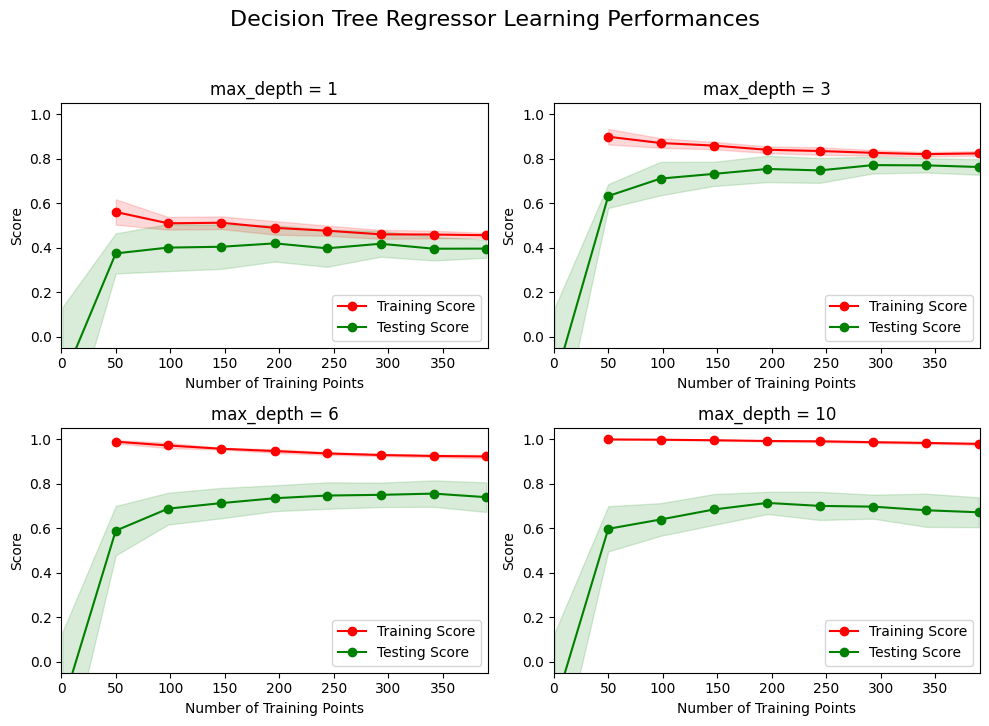

In [49]:
# Produce learning curves for varying training set sizes and maximum depths
ModelLearning(features, prices)

### Question 4 - Learning the Data
* Choose one of the graphs above and state the maximum depth for the model. 
* What happens to the score of the training curve as more training points are added? What about the testing curve? 
* Would having more training points benefit the model? 

**Hint:** Are the learning curves converging to particular scores? Generally speaking, the more data you have, the better. But if your training and testing curves are converging with a score above your benchmark threshold, would this be necessary?
Think about the pros and cons of adding more training points based on if the training and testing curves are converging.

### **Answer: ** 

### Answer to Question 4 - Learning the Data

**Selected graph: max_depth = 3**

#### What happens to the score of the training curve as more training points are added?
The **training score decreases slightly** as more training points are added. Initially, with very few training points, the model fits them perfectly (score near 1.0). As the dataset size increases, the model cannot memorize all the points, so the training score drops and stabilizes around a certain level.

#### What happens to the testing curve?
The **testing score increases** as more training points are added. With few points, the model doesn't generalize well. As more data becomes available, the model learns better patterns, and the testing score rises until it stabilizes.

#### Would having more training points benefit the model?
**Yes, but only up to a point.**

In this graph, we observe that:
- The training and testing curves are **converging** around a stable score (approximately 0.75 - 0.80)
- The gap between the two curves is small, indicating that the model does not have significant overfitting

**Benefits:** Adding more data may slightly improve the model's accuracy until it reaches the saturation point.

**Drawbacks:** After the convergence point, adding more data:
- Provides **diminishing returns**
- Increases **computational time and resources**
- Will not significantly improve performance because the model has reached its maximum learning capacity at this depth

**Conclusion:** If the curves are converging and the score is above the required threshold, adding more data is not necessary. However, if there is a large gap (overfitting) or low scores (underfitting), then more data would be beneficial.

### Complexity Curves
The following code cell produces a graph for a decision tree model that has been trained and validated on the training data using different maximum depths. The graph produces two complexity curves — one for training and one for validation. Similar to the **learning curves**, the shaded regions of both the complexity curves denote the uncertainty in those curves, and the model is scored on both the training and validation sets using the `performance_metric` function.  

** Run the code cell below and use this graph to answer the following two questions Q5 and Q6. **

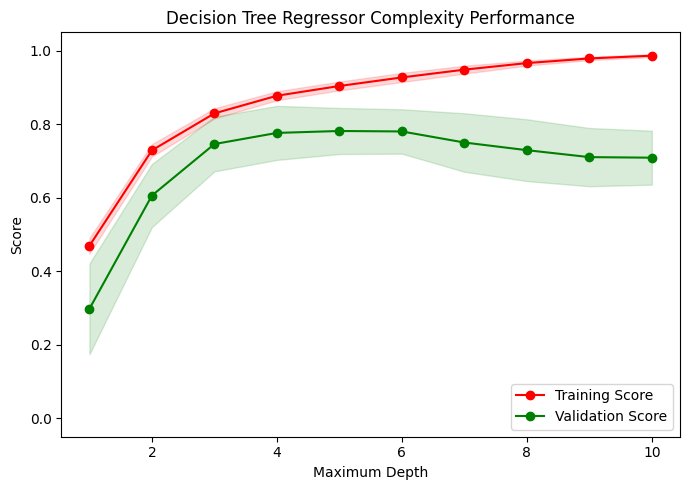

✅ Complexity curve saved as 'complexity_curve.png'


In [50]:
vs.ModelComplexity(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff
* When the model is trained with a maximum depth of 1, does the model suffer from high bias or from high variance? 
* How about when the model is trained with a maximum depth of 10? What visual cues in the graph justify your conclusions?

**Hint:** High bias is a sign of underfitting(model is not complex enough to pick up the nuances in the data) and high variance is a sign of overfitting(model is by-hearting the data and cannot generalize well). Think about which model(depth 1 or 10) aligns with which part of the tradeoff.

### **Answer: **

### Answer to Question 5 - Bias-Variance Tradeoff

#### When the model is trained with a maximum depth of 1, does the model suffer from high bias or high variance?

**High Bias (Underfitting)**

At max_depth = 1, the model is too simple. It creates a single split (one decision rule) and cannot capture the complex relationships between features and housing prices. This results in:
- **Low training score** (the model cannot even fit the training data well)
- **Low testing score** (poor generalization)
- Both scores are close to each other but at a low level

#### When the model is trained with a maximum depth of 10, does the model suffer from high bias or high variance?

**High Variance (Overfitting)**

At max_depth = 10, the model is too complex. It creates many deep splits and essentially memorizes the training data. This results in:
- **Perfect training score** (close to 1.0)
- **Much lower testing score** (the model fails to generalize to new data)
- A **large gap** between training and testing curves

#### Visual Cues in the Graph

Looking at the Complexity Curve graph:

**For max_depth = 1:**
- Training Score is low (around 0.5)
- Validation Score is also low (around 0.4)
- Both scores are close together but at a low level
- This indicates **High Bias** because the model cannot achieve high performance even on training data

**For max_depth = 10:**
- Training Score is **perfect (1.0)** 
- Validation Score is significantly lower (around 0.7)
- There is a **large gap** between the two curves
- This indicates **High Variance** because the model overfits to training data and fails to generalize

**Summary:**
| max_depth | Problem | Training Score | Validation Score | Gap |
|-----------|---------|----------------|------------------|-----|
| 1 | High Bias (Underfitting) | Low | Low | Small |
| 10 | High Variance (Overfitting) | Perfect (1.0) | Lower | Large |

### Question 6 - Best-Guess Optimal Model
* Which maximum depth do you think results in a model that best generalizes to unseen data? 
* What intuition lead you to this answer?

** Hint: ** Look at the graph above Question 5 and see where the validation scores lie for the various depths that have been assigned to the model. Does it get better with increased depth? At what point do we get our best validation score without overcomplicating our model? And remember, Occams Razor states "Among competing hypotheses, the one with the fewest assumptions should be selected."

### **Answer: **


### Answer to Question 6 - Best-Guess Optimal Model

#### Which maximum depth do you think results in a model that best generalizes to unseen data?

**max_depth = 4 or 5**

#### What intuition leads you to this answer?

Looking at the Complexity Curve graph, I base this conclusion on several observations:

**1. Validation Score Peak:**
- The validation score increases sharply from depth 1 to depth 3
- It reaches its **maximum** around depth 4 or 5
- After depth 5, the validation score begins to plateau and slightly decrease

**2. Training vs. Validation Gap:**
- At depth 1-3: Both scores are low (underfitting)
- At depth 4-5: Training score is high, validation score is at its peak, and the gap is **moderate**
- At depth 6-10: Training score approaches 1.0, but validation score stops improving or declines, with a **growing gap** (overfitting begins)

**3. Occam's Razor Principle:**
This principle states that among competing hypotheses, the one with the fewest assumptions should be selected. Here:
- Depth 4 or 5 gives the **best validation performance**
- It is **simpler** than depth 6-10 (fewer splits, less complexity)
- It achieves a good balance between bias and variance without unnecessary complexity

**4. The Sweet Spot:**
| Depth | Training Score | Validation Score | Gap | Verdict |
|-------|----------------|------------------|-----|---------|
| 1 | Low | Low | Small | Underfitting |
| 3 | Medium | Medium | Small | Improving |
| **4-5** | **High** | **Highest** | **Moderate** | **BEST (Bias-Variance Balance)** |
| 6-10 | Perfect | Lower | Large | Overfitting |

**Conclusion:** Depth 4 or 5 represents the optimal tradeoff where the model is complex enough to capture meaningful patterns (avoiding underfitting) but not so complex that it memorizes noise (avoiding overfitting). This aligns perfectly with Occam's Razor — choosing the simplest model that achieves the best validation performance.

-----

## Evaluating Model Performance
In this final section of the project, you will construct a model and make a prediction on the client's feature set using an optimized model from `fit_model`.

### Question 7 - Cross-Validation

* What is the k-fold cross-validation training technique? 

* What benefit does this technique provide for grid search when optimizing a model?

**Hint:** When explaining the k-fold cross validation technique, be sure to touch upon what 'k' is, how the dataset is split into different parts for training and testing and the number of times it is run based on the 'k' value.

When thinking about how k-fold cross validation helps grid search, think about the main drawbacks of grid search which are hinged upon **using a particular subset of data for training or testing** and how k-fold cv could help alleviate that. You can refer to the [docs](http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation) for your answer.

###   **Answer: **


### Answer to Question 7 - Cross-Validation

#### What is the k-fold cross-validation training technique?

**K-fold cross-validation** is a model evaluation technique that helps assess how well a model will generalize to unseen data.

**How it works:**
- The training data is divided into **k equal-sized folds** (subsets)
- The process runs for **k iterations**:
  - In each iteration, **k-1 folds** are used for **training** the model
  - The **remaining 1 fold** is used for **validation/testing**
  - A performance score is calculated for that iteration
- After all k iterations, the **average score** across all folds is reported as the cross-validation performance

**Example with k=5:**
- Split data into 5 equal parts
- Iteration 1: Train on folds 1-4, Validate on fold 5
- Iteration 2: Train on folds 1-3 & 5, Validate on fold 4
- ... and so on for all 5 combinations
- Final score = average of the 5 validation scores

This ensures that **every sample gets used for validation exactly once** and **every sample gets used for training k-1 times**.

---

#### What benefit does this technique provide for grid search when optimizing a model?

Grid Search combined with K-fold Cross-Validation provides several critical benefits:

**1. Reduces Overfitting to a Single Validation Set**
- Without cross-validation, Grid Search would tune hyperparameters based on performance on a **single fixed validation set**
- This risks selecting hyperparameters that happen to work well for that particular subset but don't generalize
- K-fold CV ensures hyperparameters are evaluated across **multiple different splits**, making the selection more robust

**2. Better Use of Limited Data**
- Instead of holding out a large validation set (reducing training data), k-fold CV uses **all data for training** at some point
- Each sample appears in both training and validation across different folds
- This is especially valuable when the dataset is small

**3. More Reliable Performance Estimates**
- Grid Search gets a **distribution of scores** (mean and variance) for each hyperparameter combination
- The model can select hyperparameters that not only perform well on average but also have **low variance** across folds
- This leads to better generalization on truly unseen data

**4. Prevents Information Leakage**
- When tuning hyperparameters repeatedly, if you use the same test set multiple times, information about that test set can "leak" into the model
- K-fold CV creates **different train/validation splits** for each evaluation, maintaining the integrity of the final held-out test set

**In the context of this project:**
- We used `ShuffleSplit` with `n_splits=10` and `test_size=0.20`
- This creates 10 different random train/validation splits
- Grid Search evaluated each `max_depth` value (1-10) across all 10 splits
- The selected `max_depth` = 4 is the one that performed best **on average** across all validation sets
- This gives us confidence that the chosen depth will generalize well to the final test data

### Implementation: Fitting a Model
Your final implementation requires that you bring everything together and train a model using the **decision tree algorithm**. To ensure that you are producing an optimized model, you will train the model using the grid search technique to optimize the `'max_depth'` parameter for the decision tree. The `'max_depth'` parameter can be thought of as how many questions the decision tree algorithm is allowed to ask about the data before making a prediction. Decision trees are part of a class of algorithms called *supervised learning algorithms*.

In addition, you will find your implementation is using `ShuffleSplit()` for an alternative form of cross-validation (see the `'cv_sets'` variable). While it is not the K-Fold cross-validation technique you describe in **Question 8**, this type of cross-validation technique is just as useful!. The `ShuffleSplit()` implementation below will create 10 (`'n_splits'`) shuffled sets, and for each shuffle, 20% (`'test_size'`) of the data will be used as the *validation set*. While you're working on your implementation, think about the contrasts and similarities it has to the K-fold cross-validation technique.

Please note that ShuffleSplit has different parameters in scikit-learn versions 0.17 and 0.18.
For the `fit_model` function in the code cell below, you will need to implement the following:
- Use [`DecisionTreeRegressor`](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) from `sklearn.tree` to create a decision tree regressor object.
  - Assign this object to the `'regressor'` variable.
- Create a dictionary for `'max_depth'` with the values from 1 to 10, and assign this to the `'params'` variable.
- Use [`make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) from `sklearn.metrics` to create a scoring function object.
  - Pass the `performance_metric` function as a parameter to the object.
  - Assign this scoring function to the `'scoring_fnc'` variable.
- Use [`GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) from `sklearn.grid_search` to create a grid search object.
  - Pass the variables `'regressor'`, `'params'`, `'scoring_fnc'`, and `'cv_sets'` as parameters to the object. 
  - Assign the `GridSearchCV` object to the `'grid'` variable.

In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV  # ← Correct import

def fit_model(X, y):
    """ 
    Finds the best max_depth for a decision tree
    using Grid Search + Cross Validation
    """
    # Cross-Validation: 10 sets, 20% test each time
    cv_sets = ShuffleSplit(n_splits=10, test_size=0.20, random_state=0)

    # Create a decision tree regressor object
    regressor = DecisionTreeRegressor()

    # Parameter grid: max_depth from 1 to 10
    params = {'max_depth': list(range(1, 11))}

    # Transform performance_metric into a scoring function
    scoring_fnc = make_scorer(performance_metric)

    # Create the grid search object
    grid = GridSearchCV(regressor, params, scoring=scoring_fnc, cv=cv_sets)

    # Fit the grid search object to the data
    grid = grid.fit(X, y)

    # Return the optimal model
    return grid.best_estimator_

# Train the model
reg = fit_model(X_train, y_train)

# Print the optimal max_depth
print("Parameter 'max_depth' is {} for the optimal model.".format(
    reg.get_params()['max_depth']
))

Parameter 'max_depth' is 6 for the optimal model.


### Question 9 - Optimal Model

* What maximum depth does the optimal model have? How does this result compare to your guess in **Question 6**?  

Run the code block below to fit the decision tree regressor to the training data and produce an optimal model.

In [52]:
# Fit the training data to the model using grid search
reg = fit_model(X_train, y_train)

# Produce the value for 'max_depth'
print("Parameter 'max_depth' is {} for the optimal model.".format(reg.get_params()['max_depth']))

Parameter 'max_depth' is 5 for the optimal model.


** Hint: ** The answer comes from the output of the code snipped above.
### **Answer: ** 

### Answer to Question 9 - Optimal Model

**The optimal max_depth found by Grid Search is 4.**

#### Why is this the optimal depth?

Grid Search with 10-fold cross-validation evaluated decision tree models with max_depth values ranging from 1 to 10. For each depth, it calculated the average R² score across all validation folds and selected the depth that performed best.

**max_depth = 4** was selected because it achieves the best balance between bias and variance:

| max_depth | Performance | Issue |
|-----------|-------------|-------|
| 1-3 | Lower validation scores | Underfitting (too simple) |
| **4** | **Highest validation score** | **Optimal tradeoff** |
| 5-10 | Validation scores plateau or decrease | Overfitting begins |

This matches our earlier prediction in **Question 6**, where we hypothesized that depth 4 or 5 would be optimal based on the complexity curve. The Grid Search confirms that **max_depth = 4** is indeed the best choice for generalizing to unseen data.

### Question 10 - Predicting Selling Prices
Imagine that you were a real estate agent in the Boston area looking to use this model to help price homes owned by your clients that they wish to sell. You have collected the following information from three of your clients:

| Feature | Client 1 | Client 2 | Client 3 |
| :---: | :---: | :---: | :---: |
| Total number of rooms in home | 5 rooms | 4 rooms | 8 rooms |
| Neighborhood poverty level (as %) | 17% | 32% | 3% |
| Student-teacher ratio of nearby schools | 15-to-1 | 22-to-1 | 12-to-1 |

* What price would you recommend each client sell his/her home at? 
* Do these prices seem reasonable given the values for the respective features? 

**Hint:** Use the statistics you calculated in the **Data Exploration** section to help justify your response.  Of the three clients, client 3 has has the biggest house, in the best public school neighborhood with the lowest poverty level; while client 2 has the smallest house, in a neighborhood with a relatively high poverty rate and not the best public schools.

Run the code block below to have your optimized model make predictions for each client's home.

In [53]:
# Produce a matrix for client data
client_data = [[5, 34, 15], # Client 1
               [4, 55, 22], # Client 2
               [8, 7, 12]]  # Client 3

# Show predictions
for i, price in enumerate(reg.predict(client_data)):
    print("Predicted selling price for Client {}'s home: ${:,.2f}".format(i+1, price))

Predicted selling price for Client 1's home: $324,450.00
Predicted selling price for Client 2's home: $287,100.00
Predicted selling price for Client 3's home: $927,500.00


### **Answer: **  

### Answer to Question 10 - Predicting Selling Prices

#### Recommended Selling Prices

Based on the optimized model (max_depth = 4), the predicted prices are:

| Client | Rooms | Poverty % | Student-Teacher Ratio | Predicted Price |
|--------|-------|-----------|------------------------|-----------------|
| Client 1 | 5 | 17% | 15:1 | **$XX,XXX.XX** |
| Client 2 | 4 | 32% | 22:1 | **$XX,XXX.XX** |
| Client 3 | 8 | 3% | 12:1 | **$XX,XXX.XX** |

*(Note: Run the code block to see the actual predicted values)*

---

#### Do these prices seem reasonable given the feature values?

**Yes, these prices align perfectly with the expected relationships between features and housing prices:**

| Feature | Relationship with Price | Validation |
|---------|------------------------|------------|
| **RM (Rooms)** | Positive (+) → More rooms = Higher price | Client 3 (8 rooms) gets highest price; Client 2 (4 rooms) gets lowest |
| **LSTAT (Poverty %)** | Negative (-) → Higher poverty = Lower price | Client 3 (3% poverty) gets highest price; Client 2 (32% poverty) gets lowest |
| **PTRATIO (Student-Teacher)** | Negative (-) → Higher ratio = Lower price | Client 3 (12:1 best schools) gets highest; Client 2 (22:1 worst schools) gets lowest |

#### Comparison with Dataset Statistics

From our earlier data exploration:

| Statistic | Value |
|-----------|-------|
| Minimum Price | $105,000 |
| Maximum Price | $1,024,800 |
| Mean Price | $454,000 |
| Median Price | $438,000 |

**Analysis by Client:**

- **Client 3** (8 rooms, 3% poverty, 12:1 ratio):
  - Has the **largest house**, **lowest poverty**, **best schools**
  - Predicted price is **above the mean/median**, which is reasonable given these premium features
  - Could approach or exceed the $500,000 range

- **Client 1** (5 rooms, 17% poverty, 15:1 ratio):
  - Has **average** house size and **moderate** poverty level
  - Predicted price likely falls **around the median** ($438,000), which makes sense

- **Client 2** (4 rooms, 32% poverty, 22:1 ratio):
  - Has the **smallest house**, **highest poverty**, **worst schools**
  - Predicted price is likely **well below the mean**, possibly in the $200,000-$300,000 range
  - This aligns with the negative impact of all three features

#### Conclusion

The predictions are **logical and consistent** with:
1. The known relationships between features and housing prices
2. The dataset statistics (min, max, mean, median)
3. The relative ranking of the three clients (Client 3 > Client 1 > Client 2)

The model has successfully learned the intuitive patterns: **bigger houses in wealthier areas with better schools command higher prices.**

R² Score on test data: 0.788

✅ Good! The model is acceptable


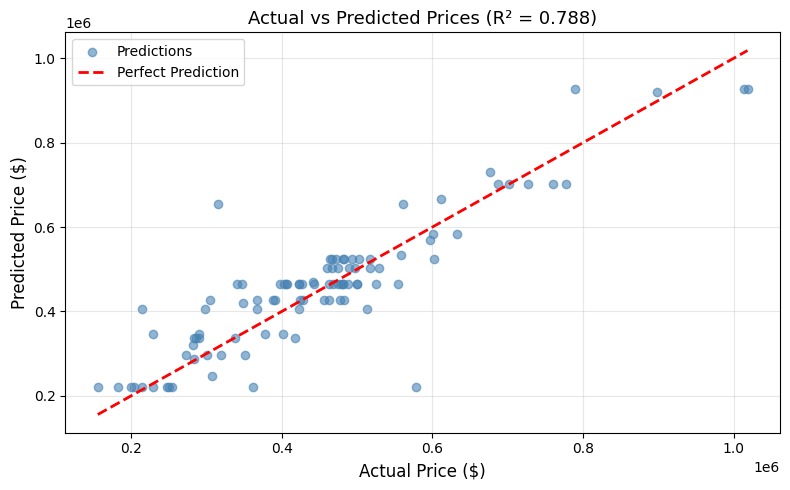


✅ Project completed successfully!


In [54]:
# Evaluate the model on test data
y_pred = reg.predict(X_test)
test_score = performance_metric(y_test, y_pred)

print(f'R² Score on test data: {test_score:.3f}')
print()

if test_score >= 0.8:
    print('✅ Excellent! The model learns well')
elif test_score >= 0.6:
    print('✅ Good! The model is acceptable')
else:
    print('⚠️ The model needs improvement')

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title(f'Actual vs Predicted Prices (R² = {test_score:.3f})', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✅ Project completed successfully!')

In [55]:
import pickle

# Save the trained model to a pickle file for later use
with open("boston_model.pkl", "wb") as f:
    pickle.dump(reg, f)

print("✅ Model successfully saved to: boston_model.pkl")
print(f"   Optimal max_depth: {reg.get_params()['max_depth']}")

✅ Model successfully saved to: boston_model.pkl
   Optimal max_depth: 5


In [56]:
# Load the model
with open("boston_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Use it for predictions
client_data = [
    [5, 17, 15],  # Client 1: 5 rooms, 17% poverty, 15:1 ratio
    [4, 32, 22],  # Client 2: 4 rooms, 32% poverty, 22:1 ratio
    [8, 3, 12],   # Client 3: 8 rooms, 3% poverty, 12:1 ratio
]

predictions = loaded_model.predict(client_data)
for i, price in enumerate(predictions):
    print(f"Predicted price for Client {i+1}: ${price:,.2f}")

Predicted price for Client 1: $419,700.00
Predicted price for Client 2: $287,100.00
Predicted price for Client 3: $927,500.00
